In [16]:
from dinocean.neverworld2.loader import *
from dinocean.neverworld2.plotter import *
import os
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
run_dir = '/scratch2/tshahriar/DINO_MITgcm_v011526_frd_runs/runs_prod/DINO-MITgcm-v011526_frd_73200d_frmSt-vAhD-vAhZ-2p00_run28463/'
grid_dir = run_dir  # change if your grid files live elsewhere

prefix = ["dynDiag"]
ref = np.datetime64("2000-01-01T00:00:00")
delta_t = 1800.0

# d = DINOLoader(run_dir, prefix=['dynDiag'], niters=240, delta_t=1800)

In [3]:
d = DINOLoader(
    run_dir=str(run_dir),          # Experiment output directory
    ref_date=ref,
    prefix=prefix,    
    niters=240,                # Number of diagnostic timesteps to load     
    delta_t=delta_t            # Model timestep in seconds (must match MITgcm deltaT)
)

In [4]:
target_lat = 26.0
d.compute_moc_diagnostics(target_lat=target_lat)

In [5]:
d.amoc_lat_sel

26.05283546447754

In [6]:
dp = DINOPlotter(d)

In [7]:
# fig, ax = dp.plot_sigma2_sections(timemean=True)
# ax.vline(-40, linestyle='--', color='grey')

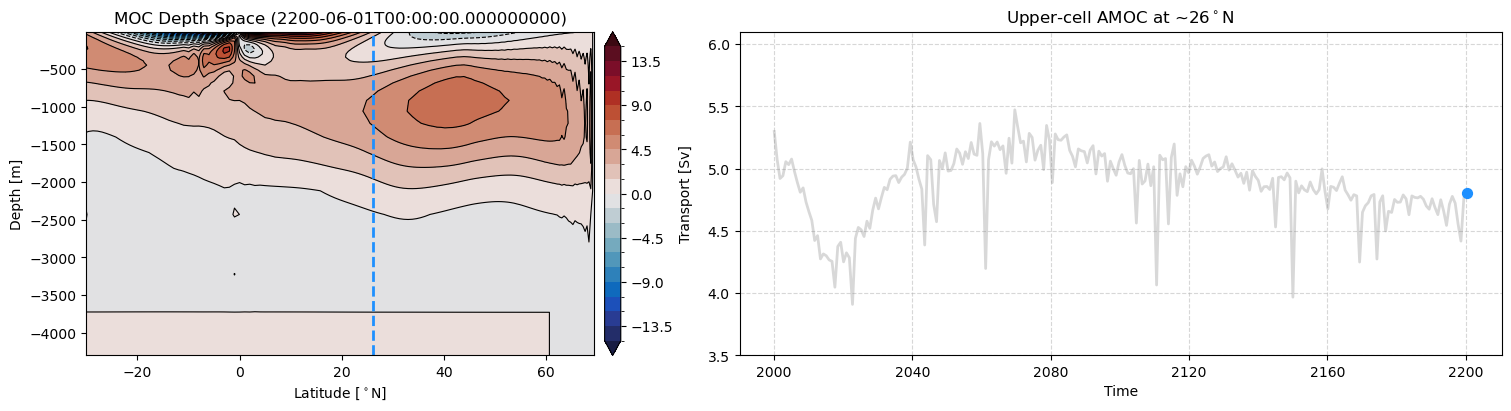

In [8]:
fig, axes = dp.plot_moc_with_amoc_timeseries(index_show=-1)
# axes[1].set_ylim([3.5, 6])
# fig.set_size_inches(20, 4)

(<Figure size 1500x600 with 3 Axes>,
 array([<Axes: title={'center': 'MOC Depth Space (2200-06-01T00:00:00.000000000)'}, xlabel='Latitude [$^\\circ$N]', ylabel='Depth [m]'>,
        <Axes: title={'center': 'Upper-cell AMOC at ~26$^\\circ$N'}, xlabel='Time'>],
       dtype=object))

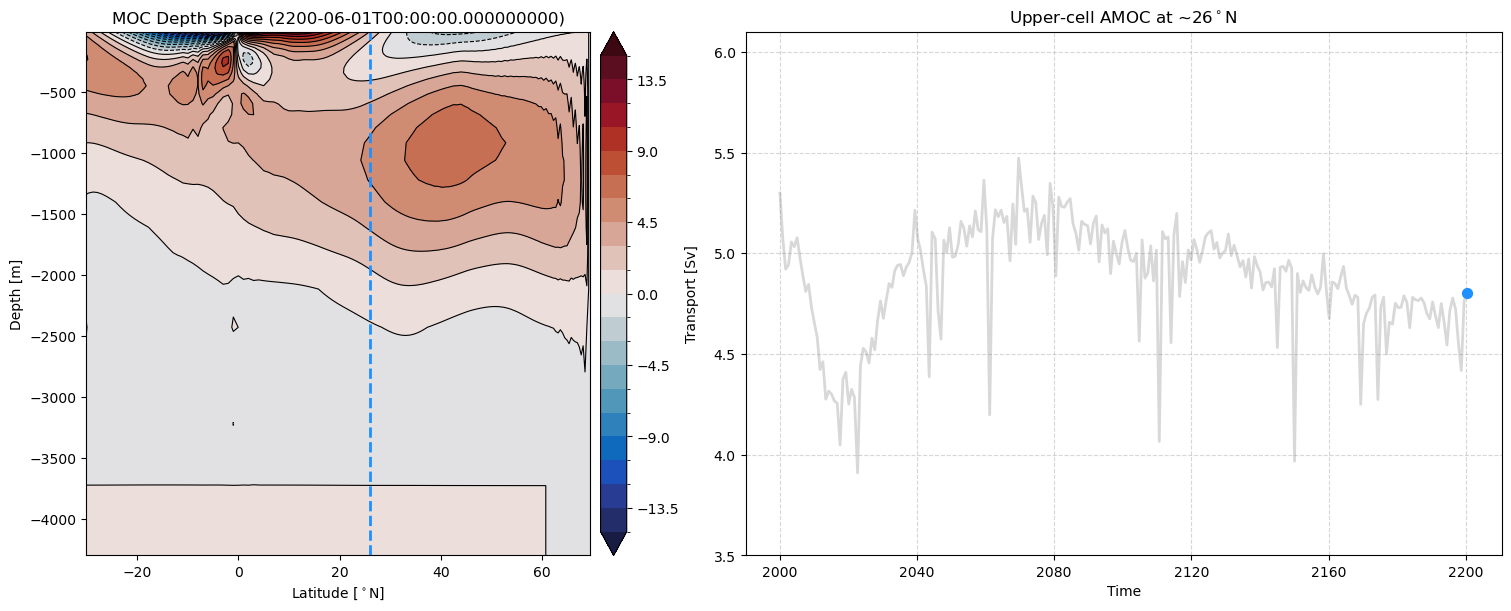

In [9]:
def modified_plot(*args, **kwargs):
    fig, axes = dp.plot_moc_with_amoc_timeseries(*args, **kwargs)
    axes[1].set_ylim([3.5, 6.1])
    fig.set_size_inches(15, 6)
    return fig, axes

modified_plot(index_show=-1)

In [10]:
from dinocean.neverworld2.gif import *

gif_dir = f'/home/tshahriar/Proj_ImPACTS/analyses/DINO_analyses/01_forward_analysis/moc_anim'
gm = GIFmaker(gif_dir, prefix="moc", dpi=100)
nt = d.ds.sizes['time']
gm.make_frames(
    nt=nt,
#    frame_func=lambda i: dp.plot_moc_with_amoc_timeseries(index_show=i),
    frame_func=lambda i: modified_plot(index_show=i),
    stride=1,
)

gm.show_slider()

gm.to_gif()

Frame 0/240
Frame 24/240
Frame 48/240
Frame 72/240
Frame 96/240
Frame 120/240
Frame 144/240
Frame 168/240
Frame 192/240
Frame 216/240


Saved GIF → /home/tshahriar/Proj_ImPACTS/analyses/DINO_analyses/01_forward_analysis/moc_anim/moc.gif


In [19]:
# ---------------------------------------------------------
# Output directory
# ---------------------------------------------------------
out_dir = '/home/tshahriar/Proj_ImPACTS/analyses/DINO_analyses/01_forward_analysis/moc_anim_jpg_std2'

os.makedirs(out_dir, exist_ok=True)

# ---------------------------------------------------------
# Number of timesteps
# ---------------------------------------------------------
nt = d.ds.sizes['time']

# ---------------------------------------------------------
# Save frames as JPG
# ---------------------------------------------------------
for i in range(0, nt, 2):

    # Your plotting function
    fig, ax = modified_plot(index_show=i)

    # Save figure
    fig.savefig(
        f'{out_dir}/moc_{i:04d}.jpg',
        dpi=100,
        bbox_inches='tight'
    )

    # Close figure
    plt.close(fig)

    print(f'Saved frame {i:04d}')

Saved frame 0000
Saved frame 0002
Saved frame 0004
Saved frame 0006
Saved frame 0008
Saved frame 0010
Saved frame 0012
Saved frame 0014
Saved frame 0016
Saved frame 0018
Saved frame 0020
Saved frame 0022
Saved frame 0024
Saved frame 0026
Saved frame 0028
Saved frame 0030
Saved frame 0032
Saved frame 0034
Saved frame 0036
Saved frame 0038
Saved frame 0040
Saved frame 0042
Saved frame 0044
Saved frame 0046
Saved frame 0048
Saved frame 0050
Saved frame 0052
Saved frame 0054
Saved frame 0056
Saved frame 0058
Saved frame 0060
Saved frame 0062
Saved frame 0064
Saved frame 0066
Saved frame 0068
Saved frame 0070
Saved frame 0072
Saved frame 0074
Saved frame 0076
Saved frame 0078
Saved frame 0080
Saved frame 0082
Saved frame 0084
Saved frame 0086
Saved frame 0088
Saved frame 0090
Saved frame 0092
Saved frame 0094
Saved frame 0096
Saved frame 0098
Saved frame 0100
Saved frame 0102
Saved frame 0104
Saved frame 0106
Saved frame 0108
Saved frame 0110
Saved frame 0112
Saved frame 0114
Saved frame 01

In [11]:
gm.to_gif()

Saved GIF → /home/tshahriar/Proj_ImPACTS/analyses/DINO_analyses/01_forward_analysis/moc_anim/moc.gif


In [12]:
gm.show_slider()
